# Hospital Utilization Analysis
**Notebook 04**

This notebook provides granular hospital utilization analytics:
- **Encounter pattern mining** — Volume trends, class transitions, time-of-day patterns
- **Length of Stay (LOS) modeling** — Statistical drivers, outlier encounters, LOS prediction factors
- **Readmission deep dive** — 30/60/90-day rates, frequent flyers, readmission risk profiling
- **ED utilization** — Avoidable visits, high-frequency users, acuity proxies
- **Capacity & seasonality** — Monthly/weekly patterns, provider workload, organizational throughput
- **Power BI-ready exports** — Utilization summary tables saved to `data/processed/`


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
COLORS = sns.color_palette('muted', 10)
HIGHLIGHT = '#e74c3c'

import os
for p in ['.', '..', '../..']:
    if os.path.exists(os.path.join(p, 'data/raw/patients.csv')):
        os.chdir(p); break

patients      = pd.read_csv('data/raw/patients.csv')
encounters    = pd.read_csv('data/raw/encounters.csv')
conditions    = pd.read_csv('data/raw/conditions.csv')
procedures    = pd.read_csv('data/raw/procedures.csv')
organizations = pd.read_csv('data/raw/organizations.csv')
providers     = pd.read_csv('data/raw/providers.csv')

patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'])
encounters['START']   = pd.to_datetime(encounters['START'], utc=True)
encounters['STOP']    = pd.to_datetime(encounters['STOP'], utc=True)

ref_date = pd.Timestamp('2020-04-01')
patients['AGE'] = patients.apply(
    lambda r: (r['DEATHDATE'] - r['BIRTHDATE']).days / 365.25
              if pd.notna(r['DEATHDATE'])
              else (ref_date - r['BIRTHDATE']).days / 365.25, axis=1).astype(int)
patients['AGE_GROUP'] = pd.cut(patients['AGE'],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=['0-17', '18-34', '35-49', '50-64', '65-79', '80+'])

encounters['DURATION_HRS'] = (encounters['STOP'] - encounters['START']).dt.total_seconds() / 3600
encounters['LOS_DAYS'] = encounters['DURATION_HRS'] / 24
encounters['YEAR'] = encounters['START'].dt.year
encounters['MONTH'] = encounters['START'].dt.month
encounters['DOW'] = encounters['START'].dt.dayofweek  # 0=Mon
encounters['HOUR'] = encounters['START'].dt.hour
encounters['OUT_OF_POCKET'] = encounters['TOTAL_CLAIM_COST'] - encounters['PAYER_COVERAGE']

os.makedirs('data/processed', exist_ok=True)
print(f"Loaded {len(encounters):,} encounters across {encounters['ENCOUNTERCLASS'].nunique()} classes")


Loaded 53,346 encounters across 6 classes


---
## 1. Encounter Pattern Mining
Volume analysis, class mix evolution, and time-based patterns.


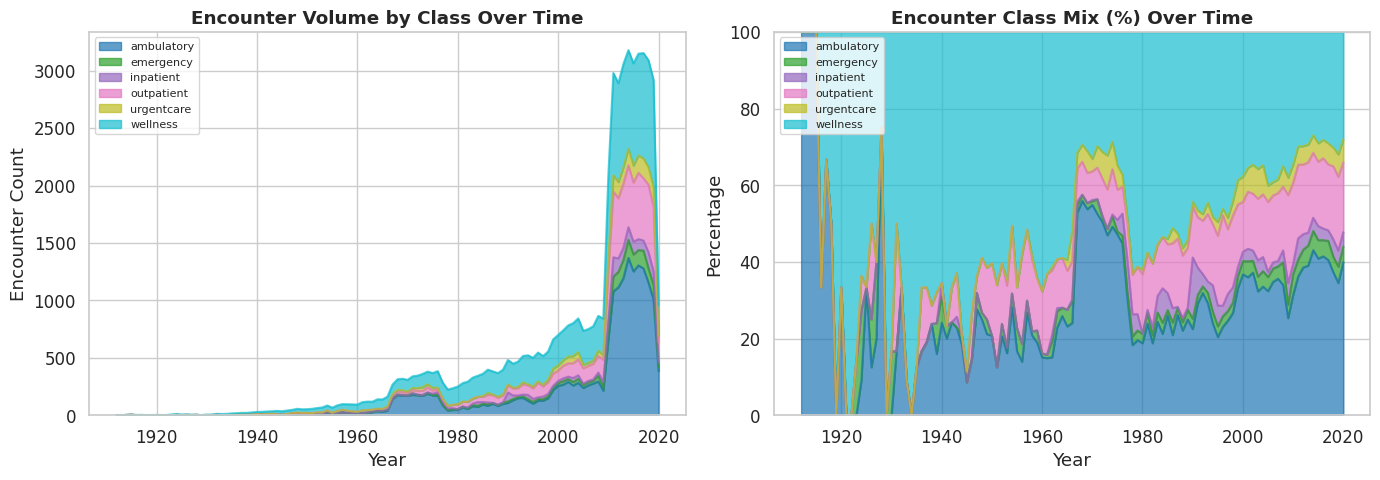

In [2]:
# 1.1 Encounter class mix evolution over time
yearly_class = encounters.groupby(['YEAR', 'ENCOUNTERCLASS']).size().unstack(fill_value=0)
yearly_pct = yearly_class.div(yearly_class.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_class.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7, colormap='tab10')
axes[0].set_title('Encounter Volume by Class Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Encounter Count')
axes[0].legend(fontsize=8, loc='upper left')

yearly_pct.plot(kind='area', stacked=True, ax=axes[1], alpha=0.7, colormap='tab10')
axes[1].set_title('Encounter Class Mix (%) Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('images/35_encounter_mix_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


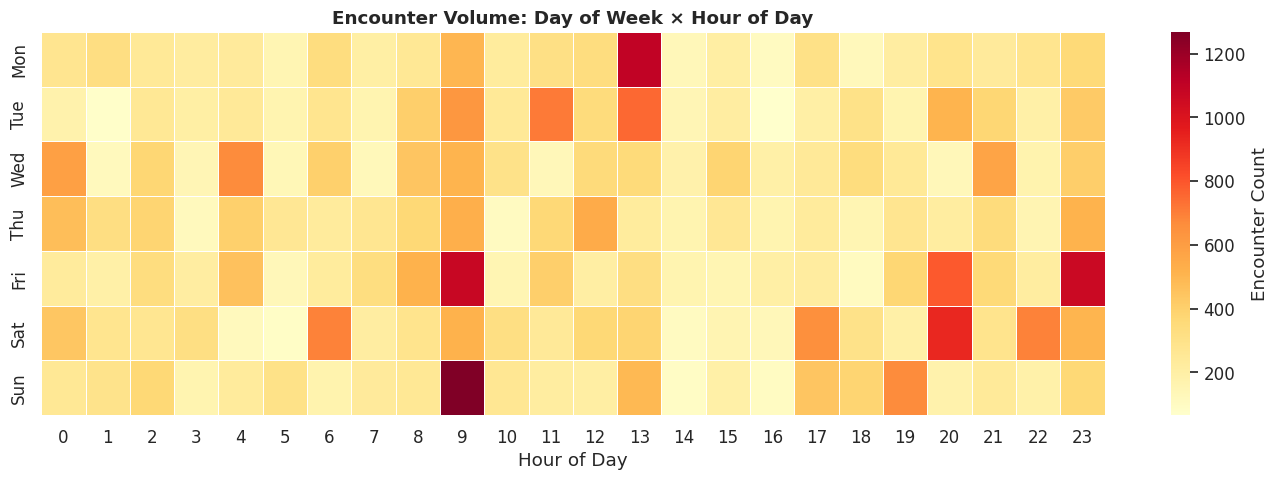

Peak day: Sat | Peak hour: 9:00


In [3]:
# 1.2 Day-of-week and hour-of-day heatmap
dow_hour = encounters.groupby(['DOW', 'HOUR']).size().reset_index(name='count')
pivot = dow_hour.pivot_table(index='DOW', columns='HOUR', values='count', fill_value=0)
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Encounter Count'})
ax.set_title('Encounter Volume: Day of Week × Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('images/36_dow_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Peak patterns
peak_dow = encounters['DOW'].value_counts().idxmax()
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(f"Peak day: {dow_names[peak_dow]} | Peak hour: {encounters['HOUR'].value_counts().idxmax()}:00")


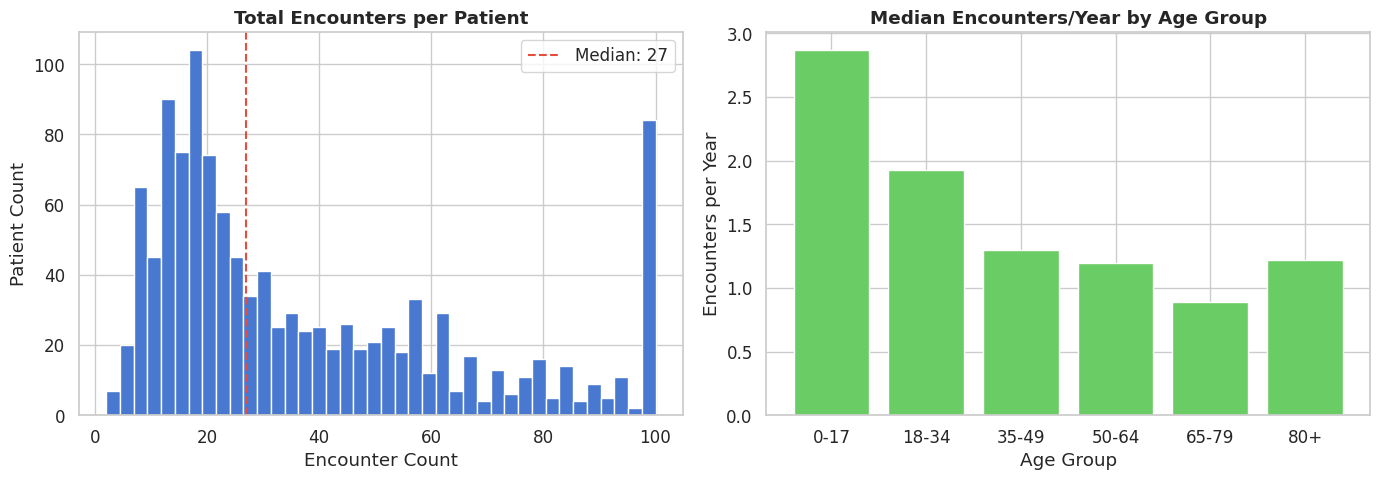

Median encounters per patient: 27
Top 5% threshold: 108 encounters


In [4]:
# 1.3 Patient encounter frequency distribution
enc_per_patient = encounters.groupby('PATIENT').agg(
    total_enc=('Id', 'count'),
    classes_used=('ENCOUNTERCLASS', 'nunique'),
    total_cost=('TOTAL_CLAIM_COST', 'sum'),
    first_visit=('START', 'min'),
    last_visit=('START', 'max')
).reset_index()
enc_per_patient = enc_per_patient.merge(patients[['Id', 'AGE', 'AGE_GROUP']], left_on='PATIENT', right_on='Id')
enc_per_patient['span_years'] = (enc_per_patient['last_visit'] - enc_per_patient['first_visit']).dt.days / 365.25
enc_per_patient['enc_per_year'] = enc_per_patient['total_enc'] / enc_per_patient['span_years'].clip(lower=0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(enc_per_patient['total_enc'].clip(upper=100), bins=40, color=COLORS[0], edgecolor='white')
axes[0].set_title('Total Encounters per Patient')
axes[0].set_xlabel('Encounter Count')
axes[0].set_ylabel('Patient Count')
axes[0].axvline(enc_per_patient['total_enc'].median(), color=HIGHLIGHT, linestyle='--',
                label=f"Median: {enc_per_patient['total_enc'].median():.0f}")
axes[0].legend()

# Encounters per year by age group
enc_yr_age = enc_per_patient.groupby('AGE_GROUP')['enc_per_year'].median()
axes[1].bar(enc_yr_age.index.astype(str), enc_yr_age.values, color=COLORS[2], edgecolor='white')
axes[1].set_title('Median Encounters/Year by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Encounters per Year')

plt.tight_layout()
plt.savefig('images/37_encounter_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median encounters per patient: {enc_per_patient['total_enc'].median():.0f}")
print(f"Top 5% threshold: {enc_per_patient['total_enc'].quantile(0.95):.0f} encounters")


---
## 2. Length of Stay (LOS) Deep Dive
Statistical analysis of inpatient and emergency LOS, drivers, and outlier identification.


In [5]:
# 2.1 LOS by encounter class — detailed statistics
los_stats = encounters[encounters['LOS_DAYS'] > 0].groupby('ENCOUNTERCLASS')['LOS_DAYS'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max',
     lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), lambda x: x.quantile(0.95)]
).round(2)
los_stats.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Q25', 'Q75', 'P95']
print("=== LOS Statistics by Encounter Class (days) ===")
print(los_stats.to_string())


=== LOS Statistics by Encounter Class (days) ===
                Count    Mean  Median      Std   Min       Max   Q25   Q75   P95
ENCOUNTERCLASS                                                                  
ambulatory      18936    0.41    0.03    18.84  0.01   2567.00  0.01  0.05  0.14
emergency        2090    1.13    0.05    49.17  0.04   2248.00  0.04  0.06  0.10
inpatient        1838   18.04    1.02   532.92  1.00  20215.19  1.00  1.08  1.17
outpatient       9003  124.73    0.01  1386.85  0.01  31920.01  0.01  0.02  0.04
urgentcare       2373    0.01    0.01     0.00  0.01      0.01  0.01  0.01  0.01
wellness        19106    0.02    0.01     0.01  0.01      0.05  0.01  0.02  0.02


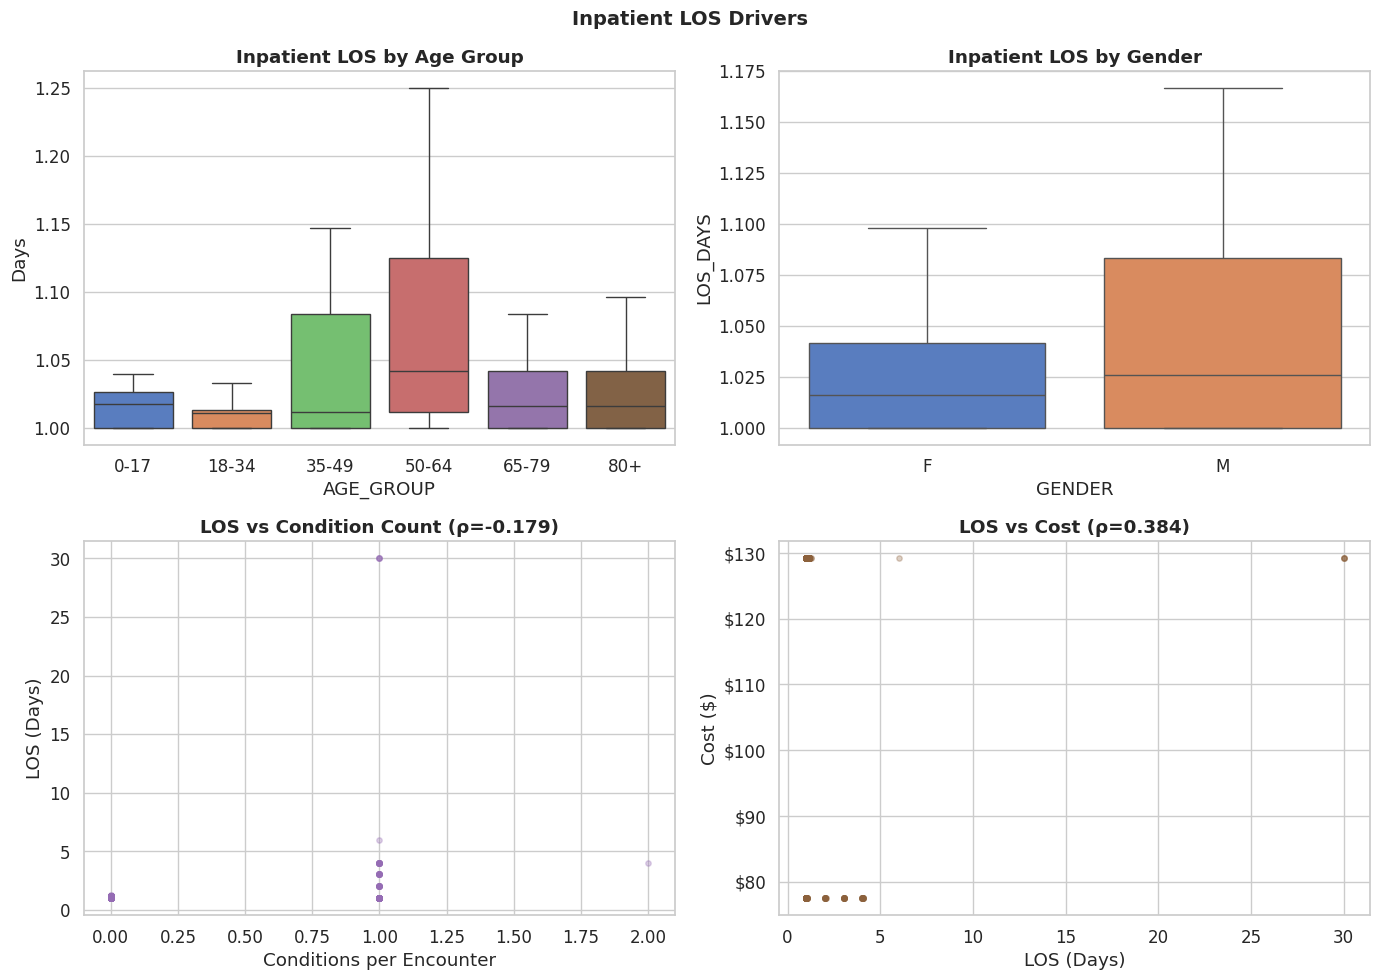

=== LOS Driver Statistical Tests ===
  Age Group (Kruskal-Wallis): H=233.55, p=0.0000
  Gender (Mann-Whitney U): U=438,442, p=0.0415


In [6]:
# 2.2 Inpatient LOS drivers — what predicts longer stays?
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()
inpatient = inpatient.merge(patients[['Id', 'AGE', 'AGE_GROUP', 'GENDER', 'RACE']],
                             left_on='PATIENT', right_on='Id', suffixes=('', '_pt'))

# Count conditions per encounter
cond_per_enc = conditions.groupby('ENCOUNTER').size().reset_index(name='condition_count')
inpatient = inpatient.merge(cond_per_enc, left_on='Id', right_on='ENCOUNTER', how='left')
inpatient['condition_count'] = inpatient['condition_count'].fillna(0)

# Count procedures per encounter
proc_per_enc = procedures.groupby('ENCOUNTER').size().reset_index(name='procedure_count')
inpatient = inpatient.merge(proc_per_enc, left_on='Id', right_on='ENCOUNTER', how='left', suffixes=('', '_proc'))
inpatient['procedure_count'] = inpatient['procedure_count'].fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LOS by age group
sns.boxplot(data=inpatient, x='AGE_GROUP', y='LOS_DAYS', ax=axes[0,0],
            palette='muted', showfliers=False)
axes[0,0].set_title('Inpatient LOS by Age Group')
axes[0,0].set_ylabel('Days')

# LOS by gender
sns.boxplot(data=inpatient, x='GENDER', y='LOS_DAYS', ax=axes[0,1],
            palette='muted', showfliers=False)
axes[0,1].set_title('Inpatient LOS by Gender')

# LOS vs number of conditions
axes[1,0].scatter(inpatient['condition_count'], inpatient['LOS_DAYS'].clip(upper=30),
                  alpha=0.3, s=15, color=COLORS[4])
r, p = spearmanr(inpatient['condition_count'], inpatient['LOS_DAYS'])
axes[1,0].set_title(f'LOS vs Condition Count (ρ={r:.3f})')
axes[1,0].set_xlabel('Conditions per Encounter')
axes[1,0].set_ylabel('LOS (Days)')

# LOS vs cost
axes[1,1].scatter(inpatient['LOS_DAYS'].clip(upper=30), inpatient['TOTAL_CLAIM_COST'],
                  alpha=0.3, s=15, color=COLORS[5])
r2, p2 = spearmanr(inpatient['LOS_DAYS'], inpatient['TOTAL_CLAIM_COST'])
axes[1,1].set_title(f'LOS vs Cost (ρ={r2:.3f})')
axes[1,1].set_xlabel('LOS (Days)')
axes[1,1].set_ylabel('Cost ($)')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Inpatient LOS Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/38_los_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical tests
print("=== LOS Driver Statistical Tests ===")
h, p = kruskal(*[g['LOS_DAYS'].values for _, g in inpatient.groupby('AGE_GROUP')])
print(f"  Age Group (Kruskal-Wallis): H={h:.2f}, p={p:.4f}")
u, p = mannwhitneyu(inpatient[inpatient['GENDER']=='M']['LOS_DAYS'],
                     inpatient[inpatient['GENDER']=='F']['LOS_DAYS'])
print(f"  Gender (Mann-Whitney U): U={u:,.0f}, p={p:.4f}")


---
## 3. Readmission Deep Dive
30/60/90-day readmission analysis, frequent flyer identification, and risk profiling.


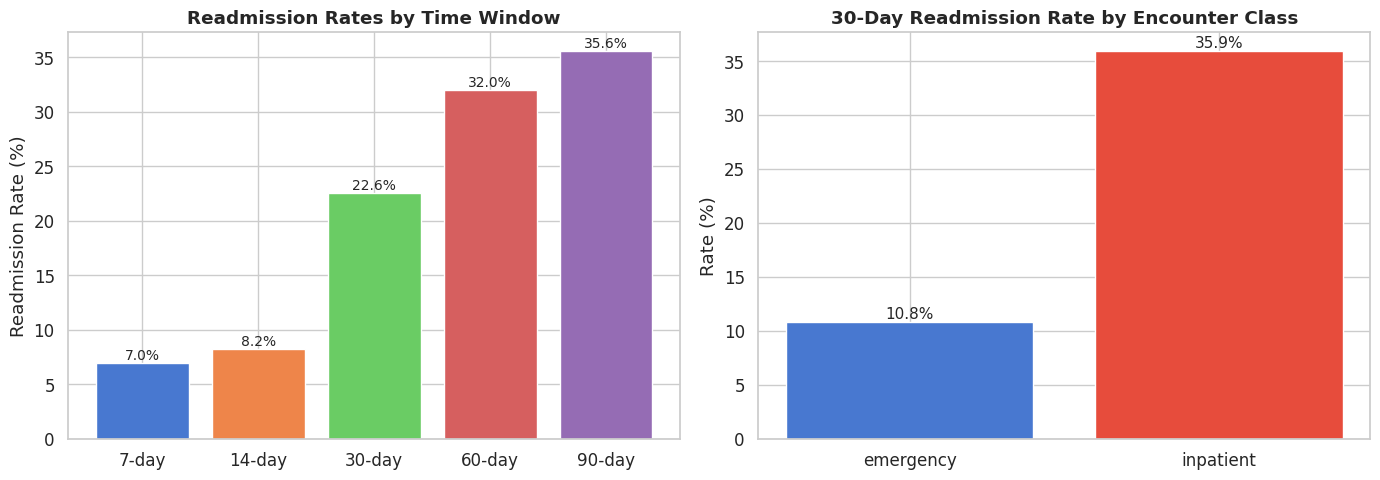

  7-day readmission rate: 7.0%
  14-day readmission rate: 8.2%
  30-day readmission rate: 22.6%
  60-day readmission rate: 32.0%
  90-day readmission rate: 35.6%


In [7]:
# 3.1 Multi-window readmission rates
acute = encounters[encounters['ENCOUNTERCLASS'].isin(['inpatient', 'emergency'])].sort_values(['PATIENT', 'START']).copy()
acute['PREV_DISCHARGE'] = acute.groupby('PATIENT')['STOP'].shift(1)
acute['DAYS_SINCE'] = (acute['START'] - acute['PREV_DISCHARGE']).dt.total_seconds() / 86400

windows = [7, 14, 30, 60, 90]
readmit_rates = {}
for w in windows:
    acute[f'readmit_{w}d'] = (acute['DAYS_SINCE'] >= 0) & (acute['DAYS_SINCE'] <= w)
    readmit_rates[f'{w}-day'] = acute[f'readmit_{w}d'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Multi-window readmission rates
axes[0].bar(readmit_rates.keys(), readmit_rates.values(), color=COLORS[:5], edgecolor='white')
axes[0].set_title('Readmission Rates by Time Window')
axes[0].set_ylabel('Readmission Rate (%)')
for i, (k, v) in enumerate(readmit_rates.items()):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# 30-day readmission by encounter class
readmit_30_class = acute.groupby('ENCOUNTERCLASS')['readmit_30d'].mean() * 100
axes[1].bar(readmit_30_class.index, readmit_30_class.values, color=[COLORS[0], HIGHLIGHT], edgecolor='white')
axes[1].set_title('30-Day Readmission Rate by Encounter Class')
axes[1].set_ylabel('Rate (%)')
for i, (idx, val) in enumerate(readmit_30_class.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('images/39_readmission_windows.png', dpi=150, bbox_inches='tight')
plt.show()

for k, v in readmit_rates.items():
    print(f"  {k} readmission rate: {v:.1f}%")


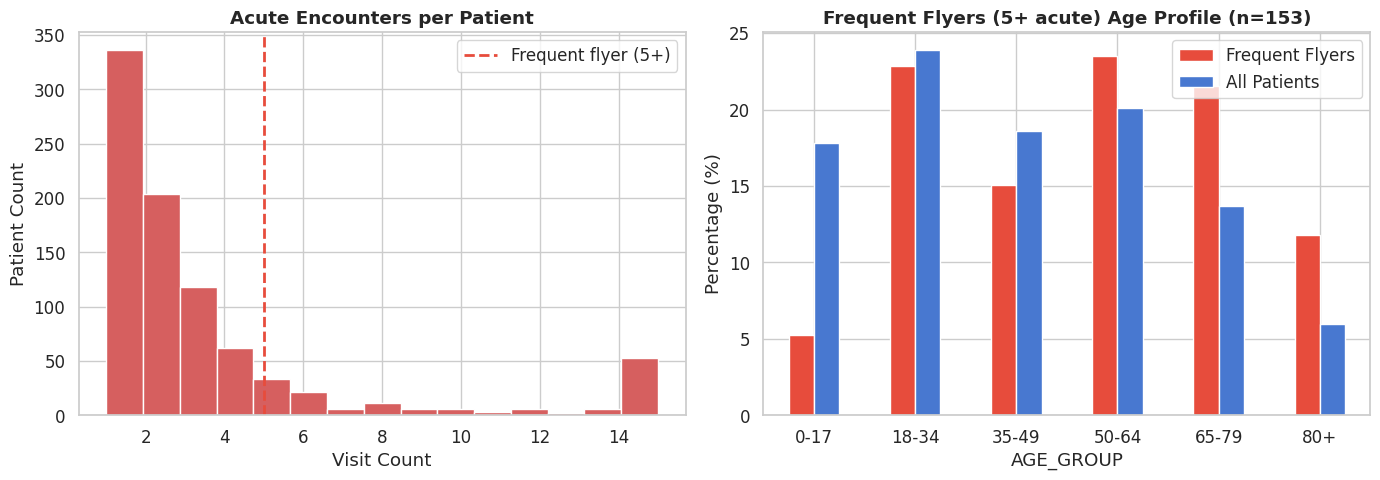

Frequent flyers (5+ acute visits): 153 patients (17.5%)
  Avg cost: $2,059 vs $556 overall


In [8]:
# 3.2 Frequent flyers — patients with most acute encounters
freq_flyers = acute.groupby('PATIENT').agg(
    acute_visits=('Id', 'count'),
    readmissions_30d=('readmit_30d', 'sum'),
    total_cost=('TOTAL_CLAIM_COST', 'sum'),
    ed_visits=('ENCOUNTERCLASS', lambda x: (x == 'emergency').sum())
).reset_index()
freq_flyers = freq_flyers.merge(patients[['Id', 'AGE', 'GENDER', 'RACE', 'AGE_GROUP']],
                                 left_on='PATIENT', right_on='Id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of acute visits
axes[0].hist(freq_flyers['acute_visits'].clip(upper=15), bins=15, color=COLORS[3], edgecolor='white')
axes[0].set_title('Acute Encounters per Patient')
axes[0].set_xlabel('Visit Count')
axes[0].set_ylabel('Patient Count')
axes[0].axvline(5, color=HIGHLIGHT, linestyle='--', linewidth=2, label='Frequent flyer (5+)')
axes[0].legend()

# Top frequent flyers profile
ff = freq_flyers[freq_flyers['acute_visits'] >= 5]
ff_age = ff['AGE_GROUP'].value_counts(normalize=True) * 100
all_age = freq_flyers['AGE_GROUP'].value_counts(normalize=True) * 100
compare = pd.DataFrame({'Frequent Flyers': ff_age, 'All Patients': all_age}).fillna(0)
compare.plot(kind='bar', ax=axes[1], color=[HIGHLIGHT, COLORS[0]], edgecolor='white')
axes[1].set_title(f'Frequent Flyers (5+ acute) Age Profile (n={len(ff)})')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('images/40_frequent_flyers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Frequent flyers (5+ acute visits): {len(ff)} patients ({len(ff)/len(freq_flyers)*100:.1f}%)")
print(f"  Avg cost: ${ff['total_cost'].mean():,.0f} vs ${freq_flyers['total_cost'].mean():,.0f} overall")


---
## 4. Emergency Department Utilization
ED visit patterns, potentially avoidable visits, and high-frequency ED users.


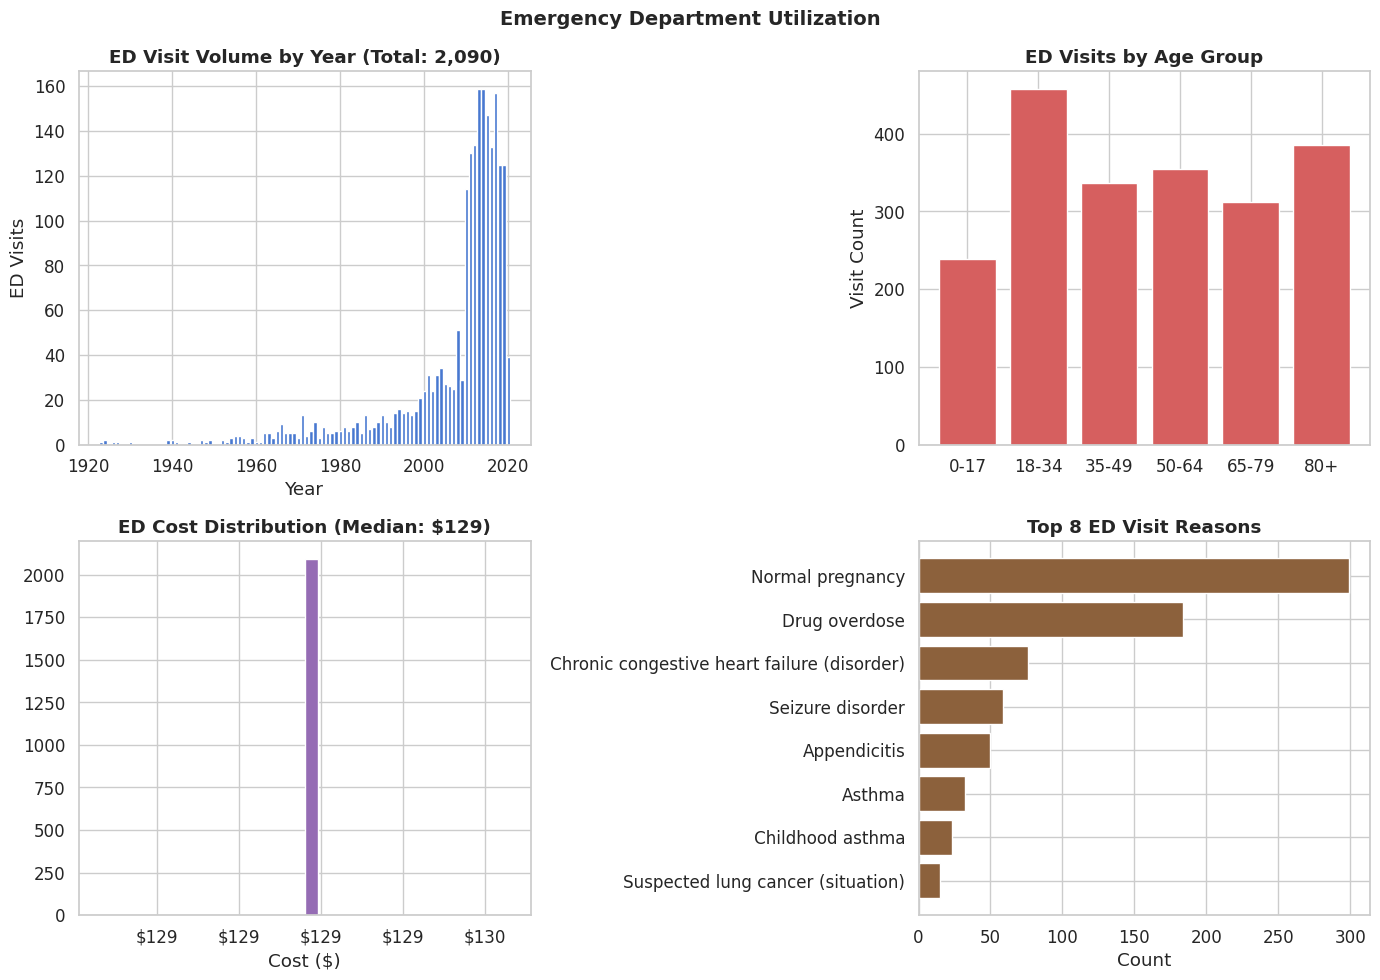

In [9]:
# 4.1 ED visit analysis
ed = encounters[encounters['ENCOUNTERCLASS'] == 'emergency'].copy()
ed = ed.merge(patients[['Id', 'AGE', 'AGE_GROUP', 'GENDER', 'RACE']], left_on='PATIENT', right_on='Id', suffixes=('', '_pt'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ED volume trend
ed_yearly = ed.groupby('YEAR').size()
axes[0,0].bar(ed_yearly.index, ed_yearly.values, color=COLORS[0], edgecolor='white')
axes[0,0].set_title(f'ED Visit Volume by Year (Total: {len(ed):,})')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('ED Visits')

# ED by age group
ed_age = ed['AGE_GROUP'].value_counts().sort_index()
axes[0,1].bar(ed_age.index.astype(str), ed_age.values, color=COLORS[3], edgecolor='white')
axes[0,1].set_title('ED Visits by Age Group')
axes[0,1].set_ylabel('Visit Count')

# ED cost distribution
axes[1,0].hist(ed['TOTAL_CLAIM_COST'], bins=30, color=COLORS[4], edgecolor='white')
axes[1,0].set_title(f'ED Cost Distribution (Median: ${ed["TOTAL_CLAIM_COST"].median():,.0f})')
axes[1,0].set_xlabel('Cost ($)')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Top ED reasons
ed_reasons = ed['REASONDESCRIPTION'].dropna().value_counts().head(8)
axes[1,1].barh(ed_reasons.index[::-1], ed_reasons.values[::-1], color=COLORS[5], edgecolor='white')
axes[1,1].set_title('Top 8 ED Visit Reasons')
axes[1,1].set_xlabel('Count')

plt.suptitle('Emergency Department Utilization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/41_ed_utilization.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# 4.2 ED frequent users
ed_per_patient = ed.groupby('PATIENT').size().reset_index(name='ed_count')
ed_per_patient = ed_per_patient.merge(patients[['Id', 'AGE_GROUP', 'RACE', 'GENDER']],
                                       left_on='PATIENT', right_on='Id')

print("=== ED Visit Frequency Distribution ===")
bins = [0, 1, 2, 3, 5, 10, 100]
labels = ['1 visit', '2 visits', '3 visits', '4-5 visits', '6-10 visits', '10+ visits']
ed_per_patient['freq_group'] = pd.cut(ed_per_patient['ed_count'], bins=bins, labels=labels, right=True)
print(ed_per_patient['freq_group'].value_counts().sort_index().to_string())

# High ED users (4+ visits) profile
high_ed = ed_per_patient[ed_per_patient['ed_count'] >= 4]
print(f"\nHigh ED users (4+ visits): {len(high_ed)} patients ({len(high_ed)/len(ed_per_patient)*100:.1f}%)")
print(f"  Age group: {high_ed['AGE_GROUP'].value_counts().head(3).to_dict()}")
print(f"  Race: {high_ed['RACE'].value_counts().head(3).to_dict()}")


=== ED Visit Frequency Distribution ===
freq_group
1 visit        401
2 visits       207
3 visits       113
4-5 visits      91
6-10 visits     34
10+ visits       5

High ED users (4+ visits): 132 patients (15.5%)
  Age group: {'18-34': 37, '65-79': 27, '35-49': 23}
  Race: {'white': 107, 'black': 12, 'asian': 7}


---
## 5. Organizational Capacity Analysis
Provider workload, organization throughput, and resource distribution.


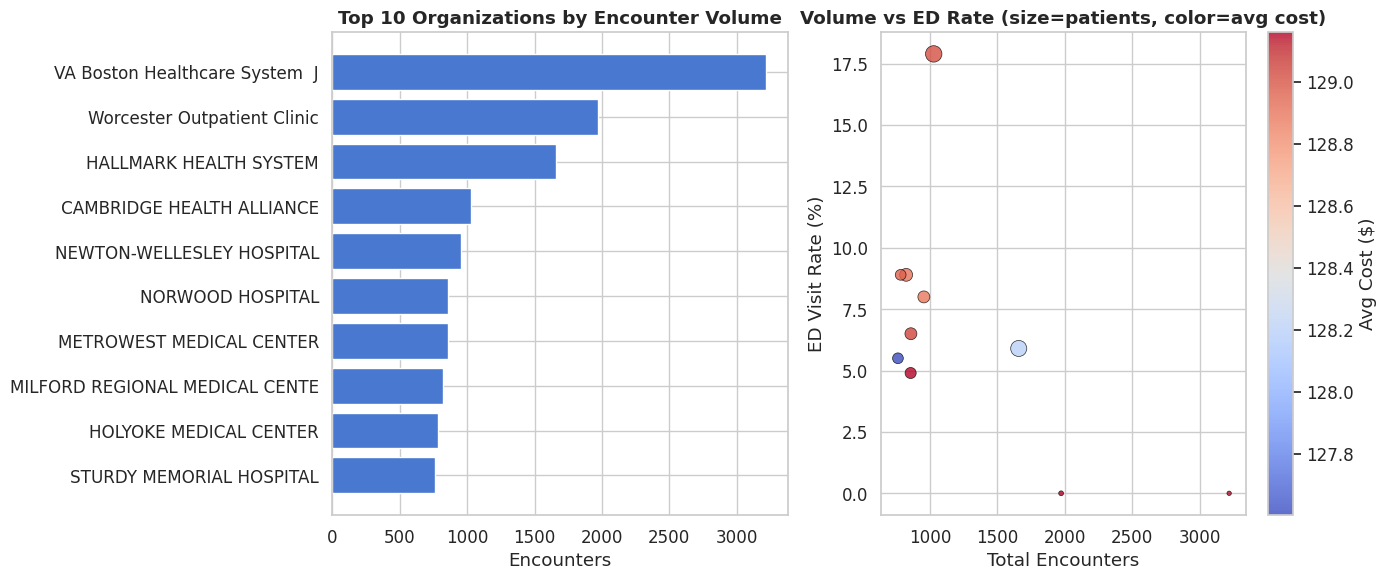

In [11]:
# 5.1 Organization performance comparison
org_enc = encounters.merge(organizations[['Id', 'NAME', 'CITY', 'REVENUE', 'UTILIZATION']],
                           left_on='ORGANIZATION', right_on='Id', suffixes=('', '_org'))

org_stats = org_enc.groupby('NAME').agg(
    encounters=('Id', 'count'),
    unique_patients=('PATIENT', 'nunique'),
    avg_cost=('TOTAL_CLAIM_COST', 'mean'),
    total_revenue=('TOTAL_CLAIM_COST', 'sum'),
    ed_visits=('ENCOUNTERCLASS', lambda x: (x == 'emergency').sum()),
    inpatient=('ENCOUNTERCLASS', lambda x: (x == 'inpatient').sum())
).reset_index().sort_values('encounters', ascending=False)
org_stats['ed_rate'] = (org_stats['ed_visits'] / org_stats['encounters'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 organizations by volume
top_orgs = org_stats.head(10)
axes[0].barh(top_orgs['NAME'].str[:30][::-1], top_orgs['encounters'][::-1], color=COLORS[0], edgecolor='white')
axes[0].set_title('Top 10 Organizations by Encounter Volume')
axes[0].set_xlabel('Encounters')

# ED rate vs volume for top orgs
scatter = axes[1].scatter(top_orgs['encounters'], top_orgs['ed_rate'],
                          s=top_orgs['unique_patients']*2, c=top_orgs['avg_cost'],
                          cmap='coolwarm', edgecolors='black', linewidth=0.5, alpha=0.8)
axes[1].set_title('Volume vs ED Rate (size=patients, color=avg cost)')
axes[1].set_xlabel('Total Encounters')
axes[1].set_ylabel('ED Visit Rate (%)')
plt.colorbar(scatter, ax=axes[1], label='Avg Cost ($)')

plt.tight_layout()
plt.savefig('images/42_organization_capacity.png', dpi=150, bbox_inches='tight')
plt.show()


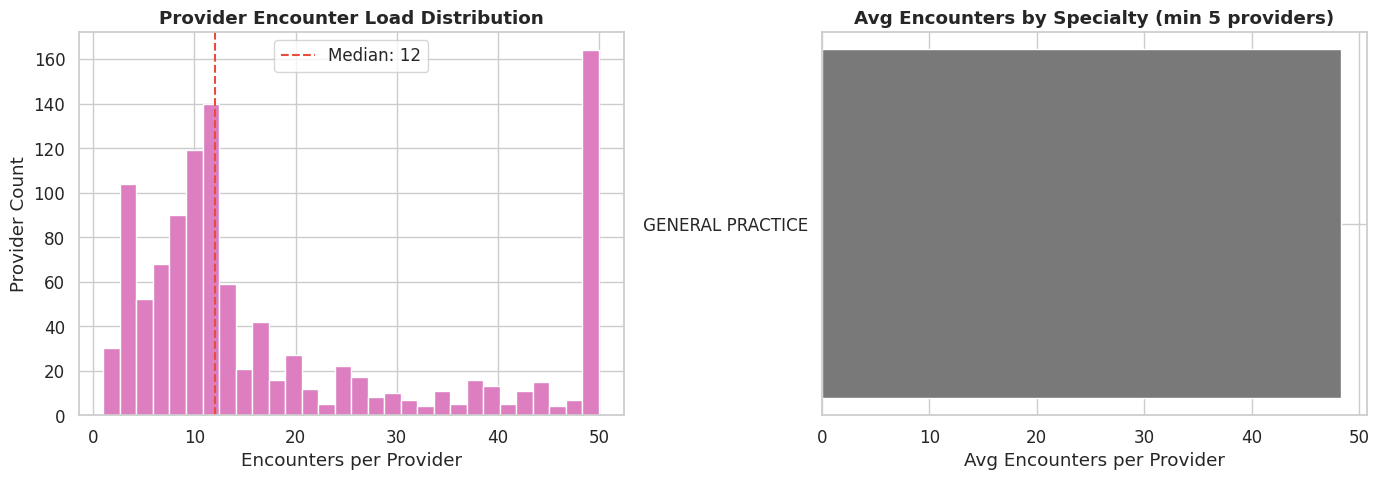

In [12]:
# 5.2 Provider workload distribution
prov_enc = encounters.groupby('PROVIDER').size().reset_index(name='encounter_count')
prov_enc = prov_enc.merge(providers[['Id', 'SPECIALITY', 'GENDER', 'UTILIZATION']],
                           left_on='PROVIDER', right_on='Id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Workload distribution
axes[0].hist(prov_enc['encounter_count'].clip(upper=50), bins=30, color=COLORS[6], edgecolor='white')
axes[0].set_title('Provider Encounter Load Distribution')
axes[0].set_xlabel('Encounters per Provider')
axes[0].set_ylabel('Provider Count')
axes[0].axvline(prov_enc['encounter_count'].median(), color=HIGHLIGHT, linestyle='--',
                label=f"Median: {prov_enc['encounter_count'].median():.0f}")
axes[0].legend()

# Top specialties by workload
spec_load = prov_enc.groupby('SPECIALITY')['encounter_count'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_spec = spec_load[spec_load['count'] >= 5].head(10)
axes[1].barh(top_spec.index[::-1], top_spec['mean'][::-1], color=COLORS[7], edgecolor='white')
axes[1].set_title('Avg Encounters by Specialty (min 5 providers)')
axes[1].set_xlabel('Avg Encounters per Provider')

plt.tight_layout()
plt.savefig('images/43_provider_workload.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Advanced Seasonality Analysis


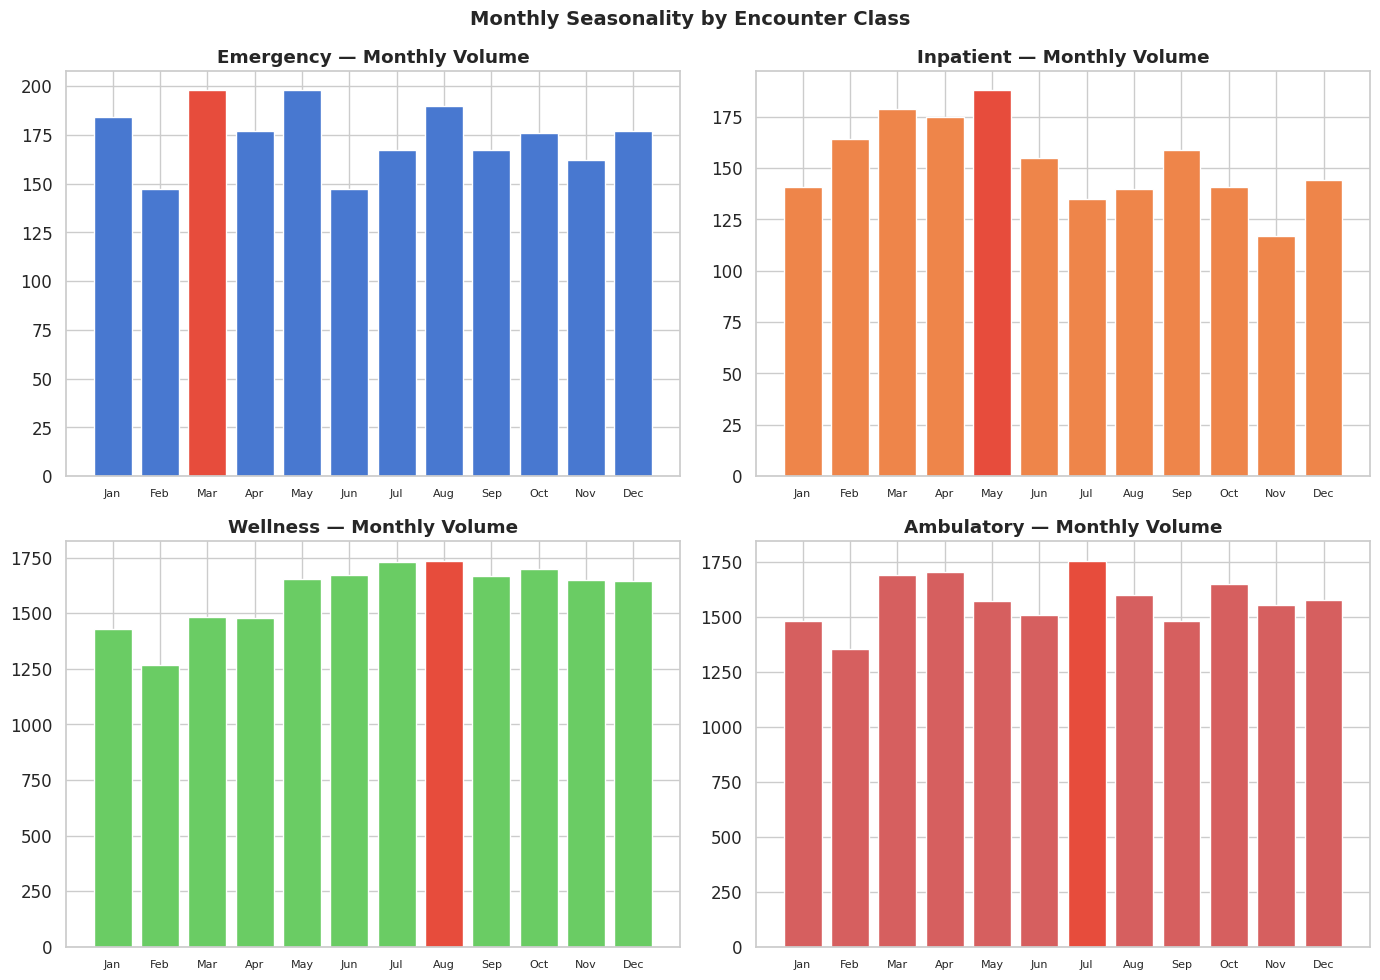

In [13]:
# 6.1 Seasonality by encounter class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, eclass in enumerate(['emergency', 'inpatient', 'wellness', 'ambulatory']):
    ax = axes[i//2, i%2]
    subset = encounters[encounters['ENCOUNTERCLASS'] == eclass]
    monthly = subset.groupby('MONTH').size()
    ax.bar(monthly.index, monthly.values, color=COLORS[i], edgecolor='white')
    ax.set_title(f'{eclass.title()} — Monthly Volume')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=8)
    
    # Highlight peak
    peak = monthly.idxmax()
    ax.patches[peak-1].set_facecolor(HIGHLIGHT)

plt.suptitle('Monthly Seasonality by Encounter Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/44_seasonality_by_class.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Power BI-Ready Exports


In [14]:
# Export utilization summary tables
enc_summary = encounters.groupby(['YEAR', 'MONTH', 'ENCOUNTERCLASS']).agg(
    encounters=('Id', 'count'),
    unique_patients=('PATIENT', 'nunique'),
    avg_cost=('TOTAL_CLAIM_COST', 'mean'),
    total_cost=('TOTAL_CLAIM_COST', 'sum'),
    avg_los_hrs=('DURATION_HRS', 'mean')
).reset_index().round(2)

org_stats.to_csv('data/processed/organization_performance.csv', index=False)
enc_summary.to_csv('data/processed/utilization_monthly.csv', index=False)
enc_per_patient.to_csv('data/processed/patient_utilization.csv', index=False)

print(f"Exported:")
print(f"  utilization_monthly.csv       ({len(enc_summary)} rows)")
print(f"  organization_performance.csv  ({len(org_stats)} rows)")
print(f"  patient_utilization.csv       ({len(enc_per_patient)} rows)")


Exported:
  utilization_monthly.csv       (4174 rows)
  organization_performance.csv  (967 rows)
  patient_utilization.csv       (1171 rows)
